In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    classification_report
)

def evaluate_experiments(plots_filter, threshold_05=False, results_folder="pipeline/results"):
    """
    Evaluates, prints metrics, and plots curves for selected ML experiments.
    
    Parameters:
    -----------
    plots_filter : list
        List of experiment names (strings) to analyze and plot.
    threshold_05 : bool, default=False
        If True, forces the standard 0.5 classification threshold.
        If False, dynamically finds the threshold that maximizes the F1-Score.
    results_folder : str, default="pipeline/results"
        Path to the directory containing the experiment CSV files.
    """
    
    # ============================================================
    # 1. DEFINE ALL EXPERIMENTS (Mapping Name to File Prefix)
    # ============================================================
    experiments_map = {
        # --- SOLO GROUPS ---
        "Baseline (Signals)": "only_baseline",
        "Only Historical": "only_historical",
        "Only Google Trends": "only_google",
        "Only INFORM Index": "only_inform",

        "Baseline (Signals) BEST": "only_baseline_best",
        "Only Historical BEST": "only_historical_best",
        "Only Google Trends BEST": "only_google_best",
        "Only INFORM Index BEST": "only_inform_best",

        # --- COMBINED GROUPS ---
        "Baseline + Historical": "baseline_historical",
        "Baseline + Google Trends": "baseline_google",
        "Baseline + INFORM": "baseline_inform",
        "Historical + Google Trends": "historical_google",
        "Historical + INFORM": "historical_inform",
        "Google Trends + INFORM": "google_inform",
        "Baseline + Historical + Google Trends": "baseline_historical_google",
        "Baseline + Historical + INFORM": "baseline_historical_inform",
        "Baseline + Google Trends + INFORM": "baseline_google_inform",
        "Historical + Google Trends + INFORM": "historical_google_inform",
        "Baseline + Historical + Google Trends + INFORM": "baseline_historical_google_inform",

        "Baseline + Historical BEST": "baseline_historical_best",
        "Baseline + Google Trends BEST": "baseline_google_best",
        "Baseline + INFORM BEST": "baseline_inform_best",
        "Historical + Google Trends BEST": "historical_google_best",
        "Historical + INFORM BEST": "historical_inform_best",
        "Google Trends + INFORM BEST": "google_inform_best",
        "Baseline + Historical + Google Trends BEST": "baseline_historical_google_best",
        "Baseline + Historical + INFORM BEST": "baseline_historical_inform_best",
        "Baseline + Google Trends + INFORM BEST": "baseline_google_inform_best",
        "Historical + Google Trends + INFORM BEST": "historical_google_inform_best",
        "Baseline + Historical + Google Trends + INFORM BEST": "baseline_historical_google_inform_best",
    }

    comparison_results = []

    # Prepare the layout (1 row, 2 columns for ROC and PR)
    fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(16, 7))

    for name, prefix in experiments_map.items():
        # Skip immediately if the model is not in the requested filter
        if name not in plots_filter:
            continue

        pred_file = os.path.join(results_folder, f"{prefix}_predictions.csv")
        feat_file = os.path.join(results_folder, f"{prefix}_feature_importance.csv")
        
        # Safety check if file wasn't generated yet
        if not os.path.exists(pred_file):
            print(f"⚠️ Warning: Missing prediction file for '{name}'. Skipping...")
            continue
            
        print(f"\n" + "="*60)
        print(f"ANALYZING EXPERIMENT: {name}")
        print("="*60)
        
        # Load raw data from disk
        df_preds = pd.read_csv(pred_file)
        all_y_true = df_preds["y_true"]
        all_y_prob = df_preds["y_prob"]

        # --- THRESHOLD STRATEGY ---
        if threshold_05:
            current_threshold = 0.5
            print("⚙️ Strategy: Using Fixed Standard Threshold (0.5)")
        else:
            # Dynamically calculate precision and recall to find the best threshold
            precisions, recalls, thresholds = precision_recall_curve(all_y_true, all_y_prob)
            # Avoid division by zero with 1e-10
            f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
            best_idx = f1_scores.argmax()
            
            # If the index is valid, select the threshold, otherwise default to 0.5
            current_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
            print(f"🎯 Strategy: Optimizing F1-Score | Best Threshold Found: {current_threshold:.3f}")

        # Convert probabilities to hard binary predictions using the selected threshold
        all_y_pred = (all_y_prob >= current_threshold).astype(int)

        # Calculate metrics
        f1 = f1_score(all_y_true, all_y_pred)
        roc_auc = roc_auc_score(all_y_true, all_y_prob)
        avg_prec = average_precision_score(all_y_true, all_y_prob)
        
        # Features count estimation from feature importance file
        num_features = len(pd.read_csv(feat_file)) if os.path.exists(feat_file) else 0
        
        comparison_results.append({
            'Experiment': name,
            'Threshold': round(current_threshold, 3),
            'F1-Score': f1,
            'AUC-ROC': roc_auc,
            'Avg Precision': avg_prec,
            'Features': num_features
        })

        # Print Top 10 Predictors if file exists
        if os.path.exists(feat_file):
            print(f"\n--- TOP 10 PREDICTORS ({name}) ---")
            df_feat = pd.read_csv(feat_file)
            print(df_feat.head(10).to_string(index=False))
        
        print(f"\nClassification Report ({name}):")
        print(classification_report(all_y_true, all_y_pred))

        # ROC Curve calculation and plotting
        fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
        ax_roc.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
        
        # PR Curve calculation and plotting
        precision, recall, _ = precision_recall_curve(all_y_true, all_y_prob)
        ax_pr.plot(recall, precision, lw=2, label=f'{name} (AP = {avg_prec:.3f})')

    # ============================================================
    # 4. FINAL RANKING TABLE
    # ============================================================
    if comparison_results:
        df_results = pd.DataFrame(comparison_results).sort_values(by='F1-Score', ascending=False)
        print("\n" + "#"*60)
        print("       FINAL RANKING (SELECTED EXPERIMENTS ONLY)")
        print("#"*60)
        print(df_results.to_string(index=False))
    else:
        print("\n❌ No experiments were successfully loaded. Plots will be empty.")
        return

    # ============================================================
    # 5. VISUALIZATION FINISHING TOUCHES
    # ============================================================
    # ROC formatting
    ax_roc.plot([0, 1], [0, 1], color='navy', linestyle='--', alpha=0.5)
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    ax_roc.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.legend(loc='lower right', fontsize=9)
    ax_roc.grid(alpha=0.3)

    # PR formatting
    ax_pr.set_xlim([0.0, 1.0])
    ax_pr.set_ylim([0.0, 1.05])
    ax_pr.set_title('Precision-Recall Curve Comparison', fontsize=14, fontweight='bold')
    ax_pr.set_xlabel('Recall')
    ax_pr.set_ylabel('Precision')
    ax_pr.legend(loc='lower left', fontsize=9)
    ax_pr.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


ANALYZING EXPERIMENT: Baseline (Signals)
🎯 Strategy: Optimizing F1-Score | Best Threshold Found: 0.628

--- TOP 10 PREDICTORS (Baseline (Signals)) ---
                 feature  importance
rolling_3m_displacements    0.180965
             disp_6m_avg    0.167845
           logfat_risk_3    0.134191
          logfat_risk_12    0.098244
    monthly_displacement    0.088352
                  risk_3    0.074502
                 risk_12    0.067114
              fat_6m_avg    0.058131
              risk_gt_06    0.039731
              fatalities    0.029984

Classification Report (Baseline (Signals)):
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99      3949
         1.0       0.84      0.77      0.80       275

    accuracy                           0.98      4224
   macro avg       0.91      0.88      0.90      4224
weighted avg       0.97      0.98      0.98      4224


ANALYZING EXPERIMENT: Only INFORM Index
🎯 Strategy: Optimizing F1-Sc

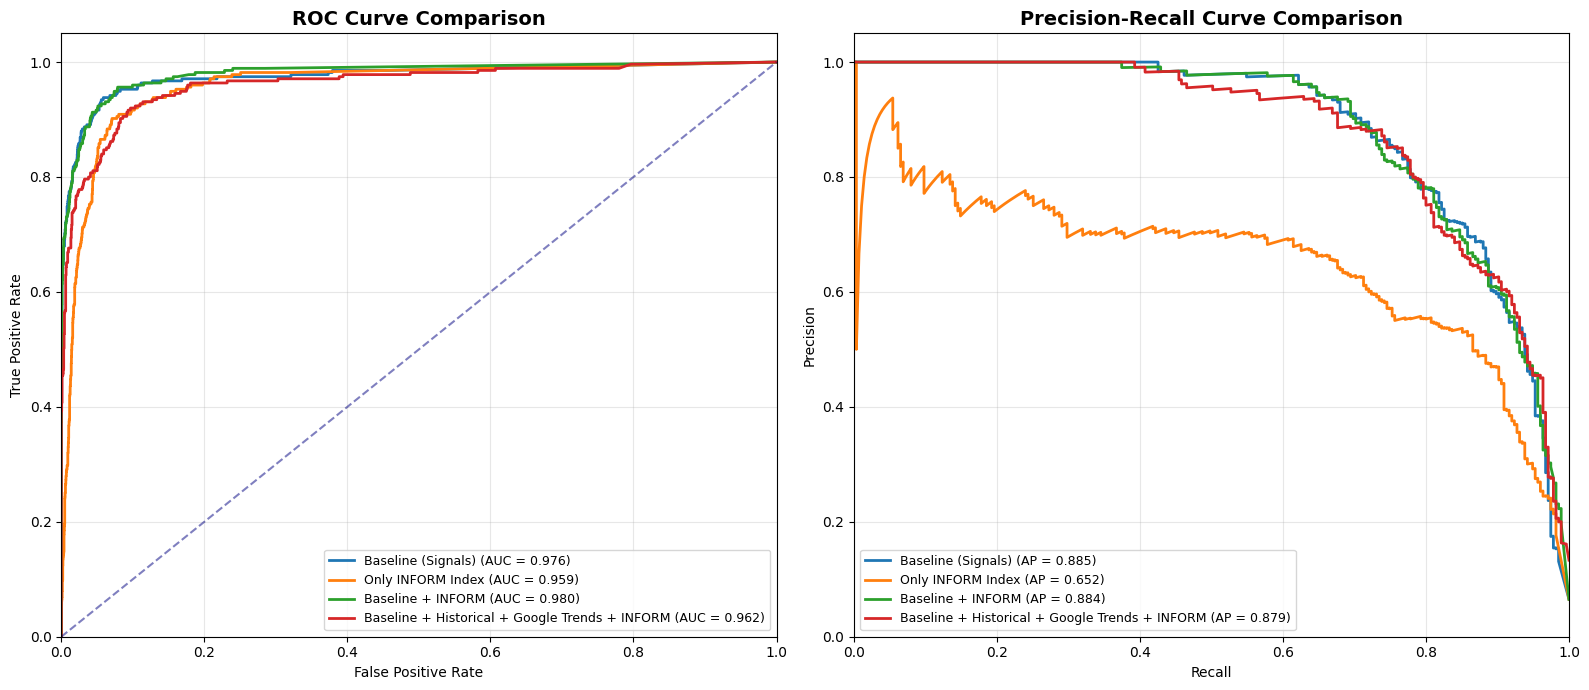

In [4]:
models_to_evaluate = [
    "Baseline (Signals)",
    "Only INFORM Index",
    "Baseline + INFORM",
    "Baseline + Historical + Google Trends + INFORM"
]

evaluate_experiments(plots_filter=models_to_evaluate, threshold_05=False)